In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Ready to reshape some vectors!")

Ready to reshape some vectors!


In [2]:
alice = np.array([8.0, 5.0, 50.0])
bob = np.array([3.0, 9.0, 20.0])

dot = np.dot(alice, bob)
cos_sim = dot / (np.linalg.norm(alice) * np.linalg.norm(bob))
print(f"Alice's feature vector: {alice}")
print(f"Bob's feature vector:   {bob}")
print(f"Dot product:  {dot:.2f}")
print(f"Cosine similarity:  {cos_sim:.4f}")
print(f"L2 distance: {np.linalg.norm(alice - bob):.4f}")

Alice's feature vector: [ 8.  5. 50.]
Bob's feature vector:   [ 3.  9. 20.]
Dot product:  1069.00
Cosine similarity:  0.9491
L2 distance: 30.6757


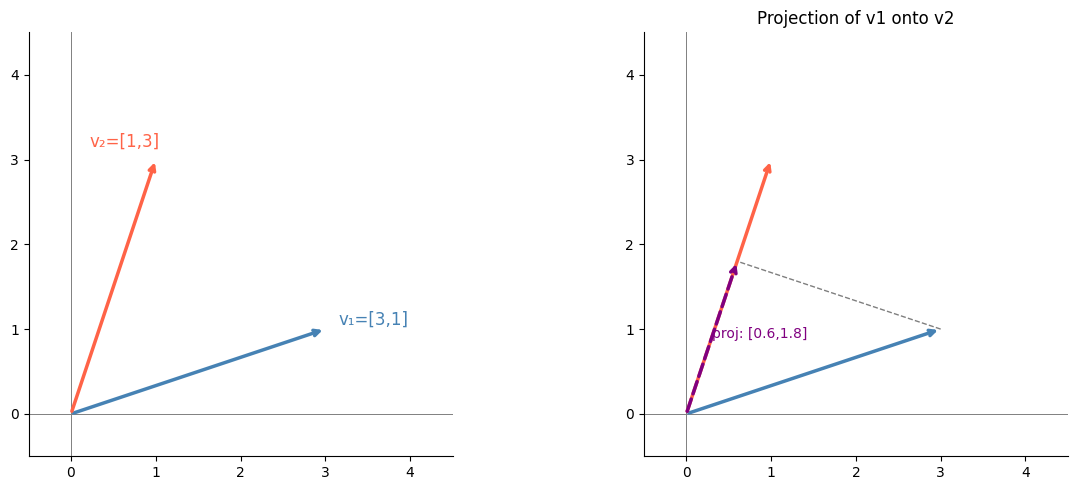

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
v1 = np.array([3, 1])
v2 = np.array([1, 3])

ax = axes[0]
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 4.5)
ax.axhline(0, color='gray', lw=0.7); ax.axvline(0, color='gray', lw=0.7)
ax.annotate('', xy=v1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.annotate('', xy=v2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='tomato', lw=2.5))
ax.text(*v1*1.05, 'v₁=[3,1]', fontsize=12, color='steelblue', ha='left')
ax.text(*v2*1.05, 'v₂=[1,3]', fontsize=12, color='tomato', ha='right')
angle = np.degrees(np.arccos(np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))))
Dot_product = {np.dot(v1,v2)}
ax.set_aspect('equal')

proj = (np.dot(v1, v2) / np.dot(v2, v2)) * v2
ax2 = axes[1]
ax2.set_xlim(-0.5, 4.5); ax2.set_ylim(-0.5, 4.5)
ax2.axhline(0, color='gray', lw=0.7); ax2.axvline(0, color='gray', lw=0.7)
ax2.annotate('', xy=v1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax2.annotate('', xy=v2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='tomato', lw=2.5))
ax2.annotate('', xy=proj, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='purple', lw=2.5, ls='--'))
ax2.plot([v1[0], proj[0]], [v1[1], proj[1]], 'k--', lw=1, alpha=0.5)
ax2.text(*proj*0.5, f'proj: [{proj[0]:.1f},{proj[1]:.1f}]', color='purple', fontsize=10)
ax2.set_title('Projection of v1 onto v2')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()


In [4]:
def matmul_scratch(A, B):
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, f"Shape mismatch: shape of A = {A.shape}, shape of B = {B.shape}"

    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for l in range(k):
                C[i, j] += A[i, l] * B[l, j]
    return C

A = np.array([[1, 2, 3], [4, 5, 6]], dtype=float)  
B = np.array([[7, 8], [9, 10], [11, 12]], dtype=float) 

C_scratch = matmul_scratch(A, B)
C_numpy   = A @ B

print("Matrix A (2×3):")
print(A)
print("\nMatrix B (3×2):")
print(B)
print("\nC = A @ B  (our implementation):")
print(C_scratch)
print("\nVerification against NumPy:", np.allclose(C_scratch, C_numpy))
print("\nUnderstanding: C[0,0] = row0(A)·col0(B) = 1×7 + 2×9 + 3×11 =", 1*7+2*9+3*11)

Matrix A (2×3):
[[1. 2. 3.]
 [4. 5. 6.]]

Matrix B (3×2):
[[ 7.  8.]
 [ 9. 10.]
 [11. 12.]]

C = A @ B  (our implementation):
[[ 58.  64.]
 [139. 154.]]

Verification against NumPy: True

Understanding: C[0,0] = row0(A)·col0(B) = 1×7 + 2×9 + 3×11 = 58


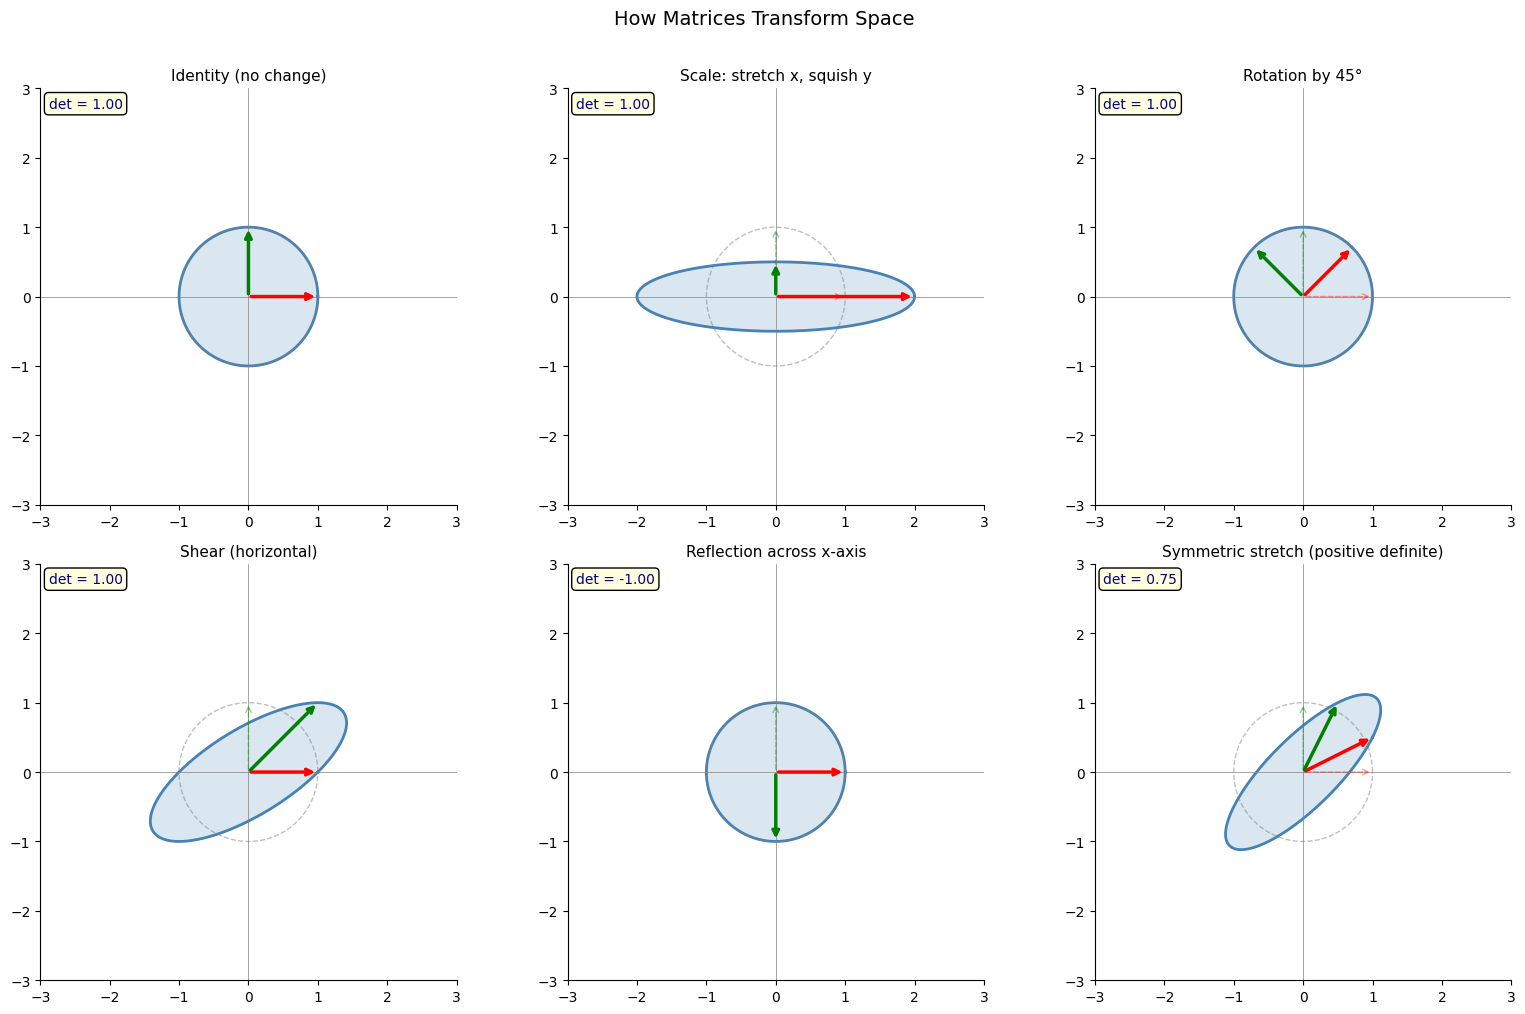

In [8]:
def transform_and_plot(M, title, ax):
    theta = np.linspace(0, 2*np.pi, 200)
    circle = np.array([np.cos(theta), np.sin(theta)])
    transformed = M @ circle

    e1, e2 = np.array([1, 0]), np.array([0, 1])
    Me1, Me2 = M @ e1, M @ e2
    ax.fill(transformed[0], transformed[1], alpha=0.2, color='steelblue')
    ax.plot(transformed[0], transformed[1], 'steelblue', lw=2)
    ax.plot(circle[0], circle[1], 'gray', lw=1, ls='--', alpha=0.5)
    arrow_kw = dict(arrowstyle='->', lw=2.5)
    ax.annotate('', xy=Me1, xytext=(0,0), arrowprops=dict(**arrow_kw, color='red'))
    ax.annotate('', xy=Me2, xytext=(0,0), arrowprops=dict(**arrow_kw, color='green'))
    ax.annotate('', xy=e1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='red', lw=1, ls='dashed', alpha=0.4))
    ax.annotate('', xy=e2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='green', lw=1, ls='dashed', alpha=0.4))

    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    lim = max(3, np.abs(transformed).max() * 1.3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.text(0.02, 0.98, f'det = {np.linalg.det(M):.2f}', transform=ax.transAxes,
            va='top', fontsize=10, color='navy',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
transforms = [
    (np.eye(2), 'Identity (no change)'),
    (np.array([[2,0],[0,0.5]]), 'Scale: stretch x, squish y'),
    (np.array([[np.cos(np.pi/4),-np.sin(np.pi/4)],[np.sin(np.pi/4),np.cos(np.pi/4)]]), 'Rotation by 45°'),
    (np.array([[1,1],[0,1]]), 'Shear (horizontal)'),
    (np.array([[1,0],[0,-1]]), 'Reflection across x-axis'),
    (np.array([[1,0.5],[0.5,1]]), 'Symmetric stretch (positive definite)'),
]

for (M, title), ax in zip(transforms, axes.flat):
    transform_and_plot(M, title, ax)

plt.suptitle('How Matrices Transform Space', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()